# Assignment 2

### Task 1: Retrieving and Preparing the Data	

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mticker

In [2]:
filename ='Dataset 1 - Dry Bean/Dry_Bean_dataset.csv'
df = pd.read_csv(filename)

In [3]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [4]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [6]:
df['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

In [7]:
df.dtypes

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

In [8]:
df['Class'] = df['Class'].astype('category')

In [9]:
df.duplicated().sum()

np.int64(68)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(13543, 17)

## Task 2: Data Exploration

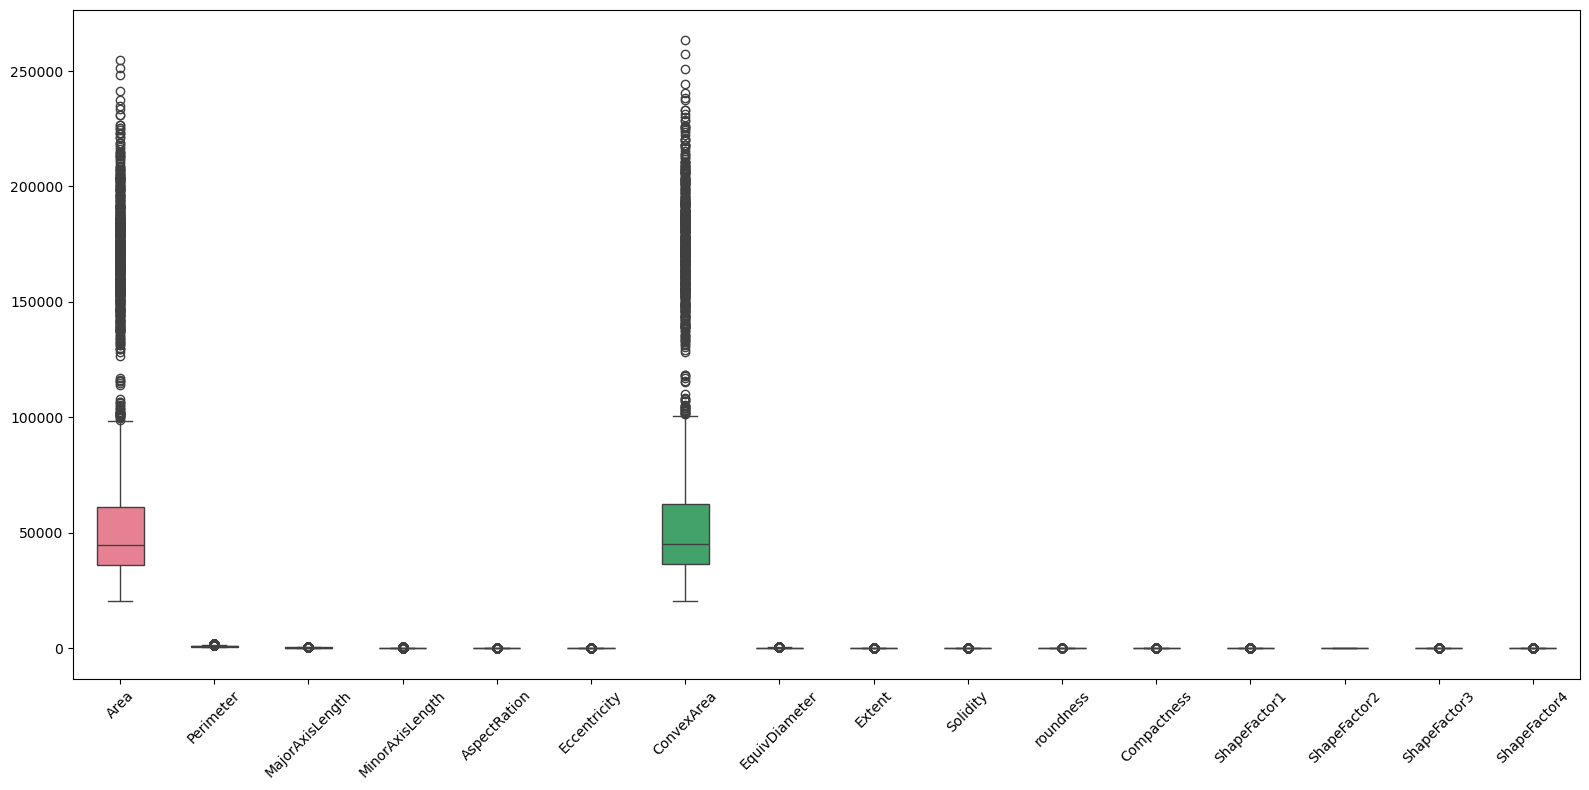

In [13]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df,width=.5)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

In [14]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median = df[col].median()
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median

In [15]:
df.shape

(13543, 17)

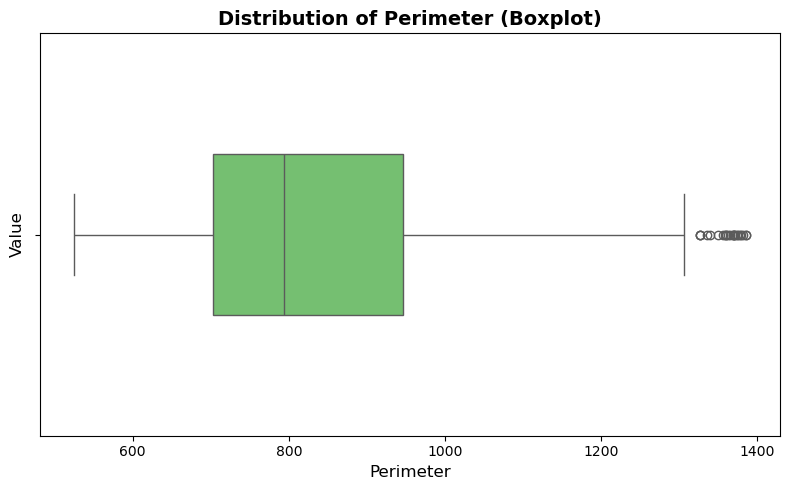

In [16]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Boxplot with styling
sns.boxplot(
    data=df,
    x='Perimeter',
    ax=ax,
    width=0.4,
    color=sns.color_palette('muted')[2]
)

# Title and labels
ax.set_title('Distribution of Perimeter (Boxplot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Perimeter', fontsize=12)
ax.set_ylabel('Value', fontsize=12)

# # Format x-axis numbers (same style as your KDE/hist grid)
# ax.xaxis.set_major_formatter(
#     mticker.FuncFormatter(
#         lambda x, _: f'{x:,.0f}' if abs(x) > 999 else f'{x:.2f}'
#     )
# )

# Clean layout
plt.tight_layout()

# Save high‑quality figure
plt.savefig('perimeter_boxplot.png', bbox_inches='tight', dpi=150)

plt.show()

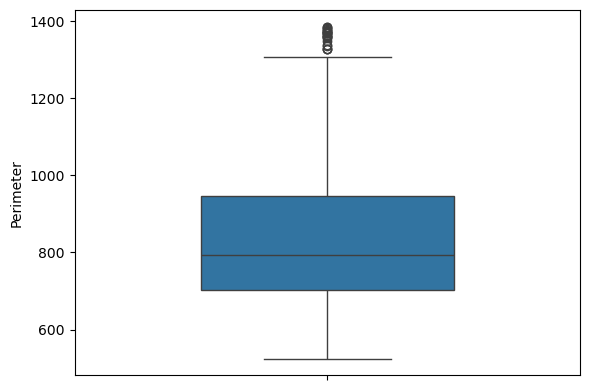

In [17]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Perimeter'],width=.5)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

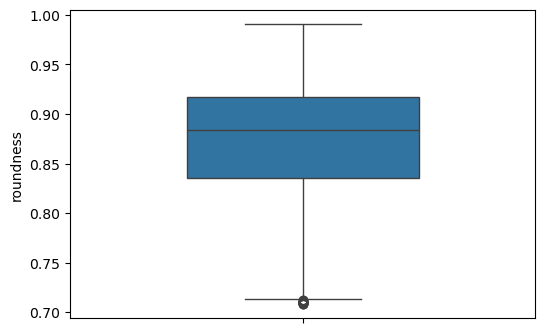

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['roundness'],width=.5)
plt.show()

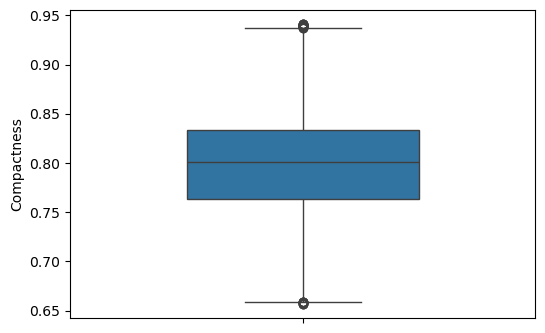

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Compactness'],width=.5)
plt.show()

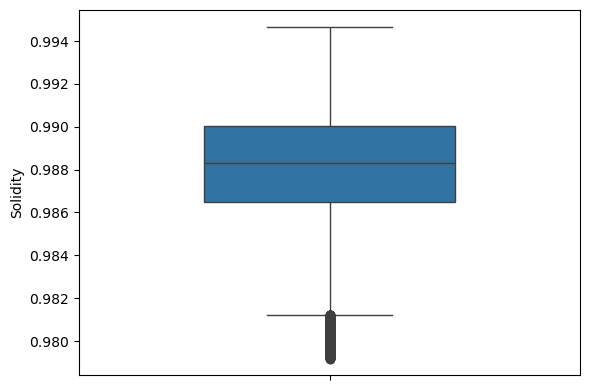

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Solidity'],width=.5)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

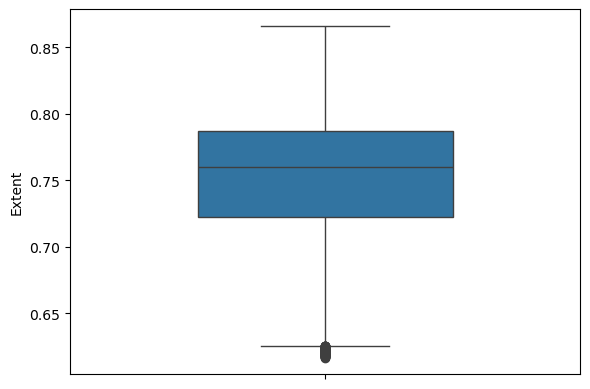

In [21]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Extent'],width=.5)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

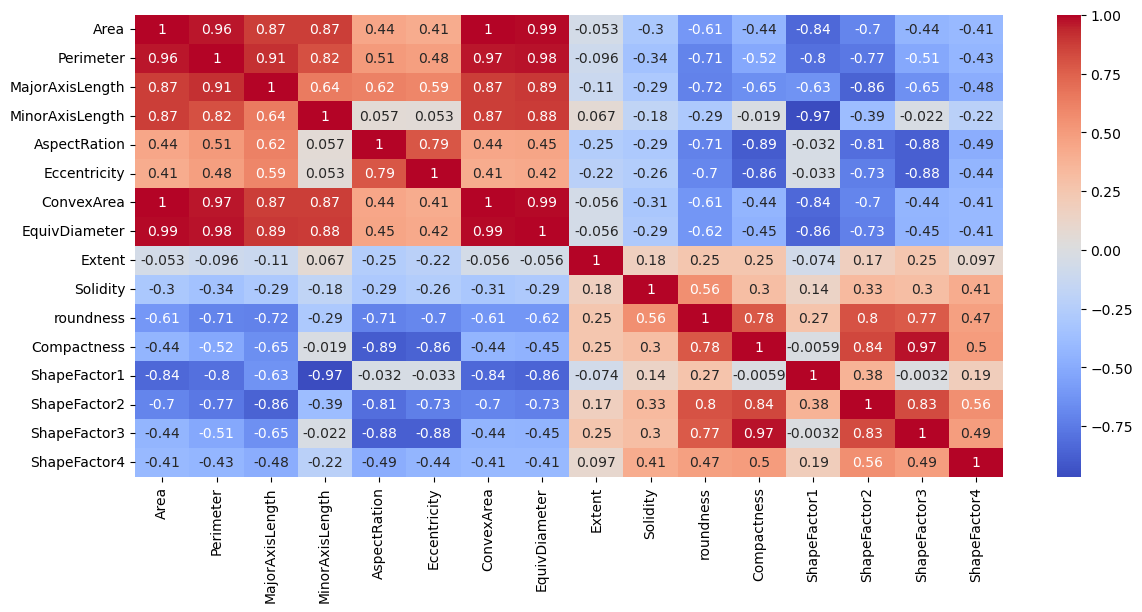

In [22]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()
plt.figure(figsize=(14, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Select only the numeric columns.

In [23]:
numeric_cols = df.select_dtypes(include='number').columns

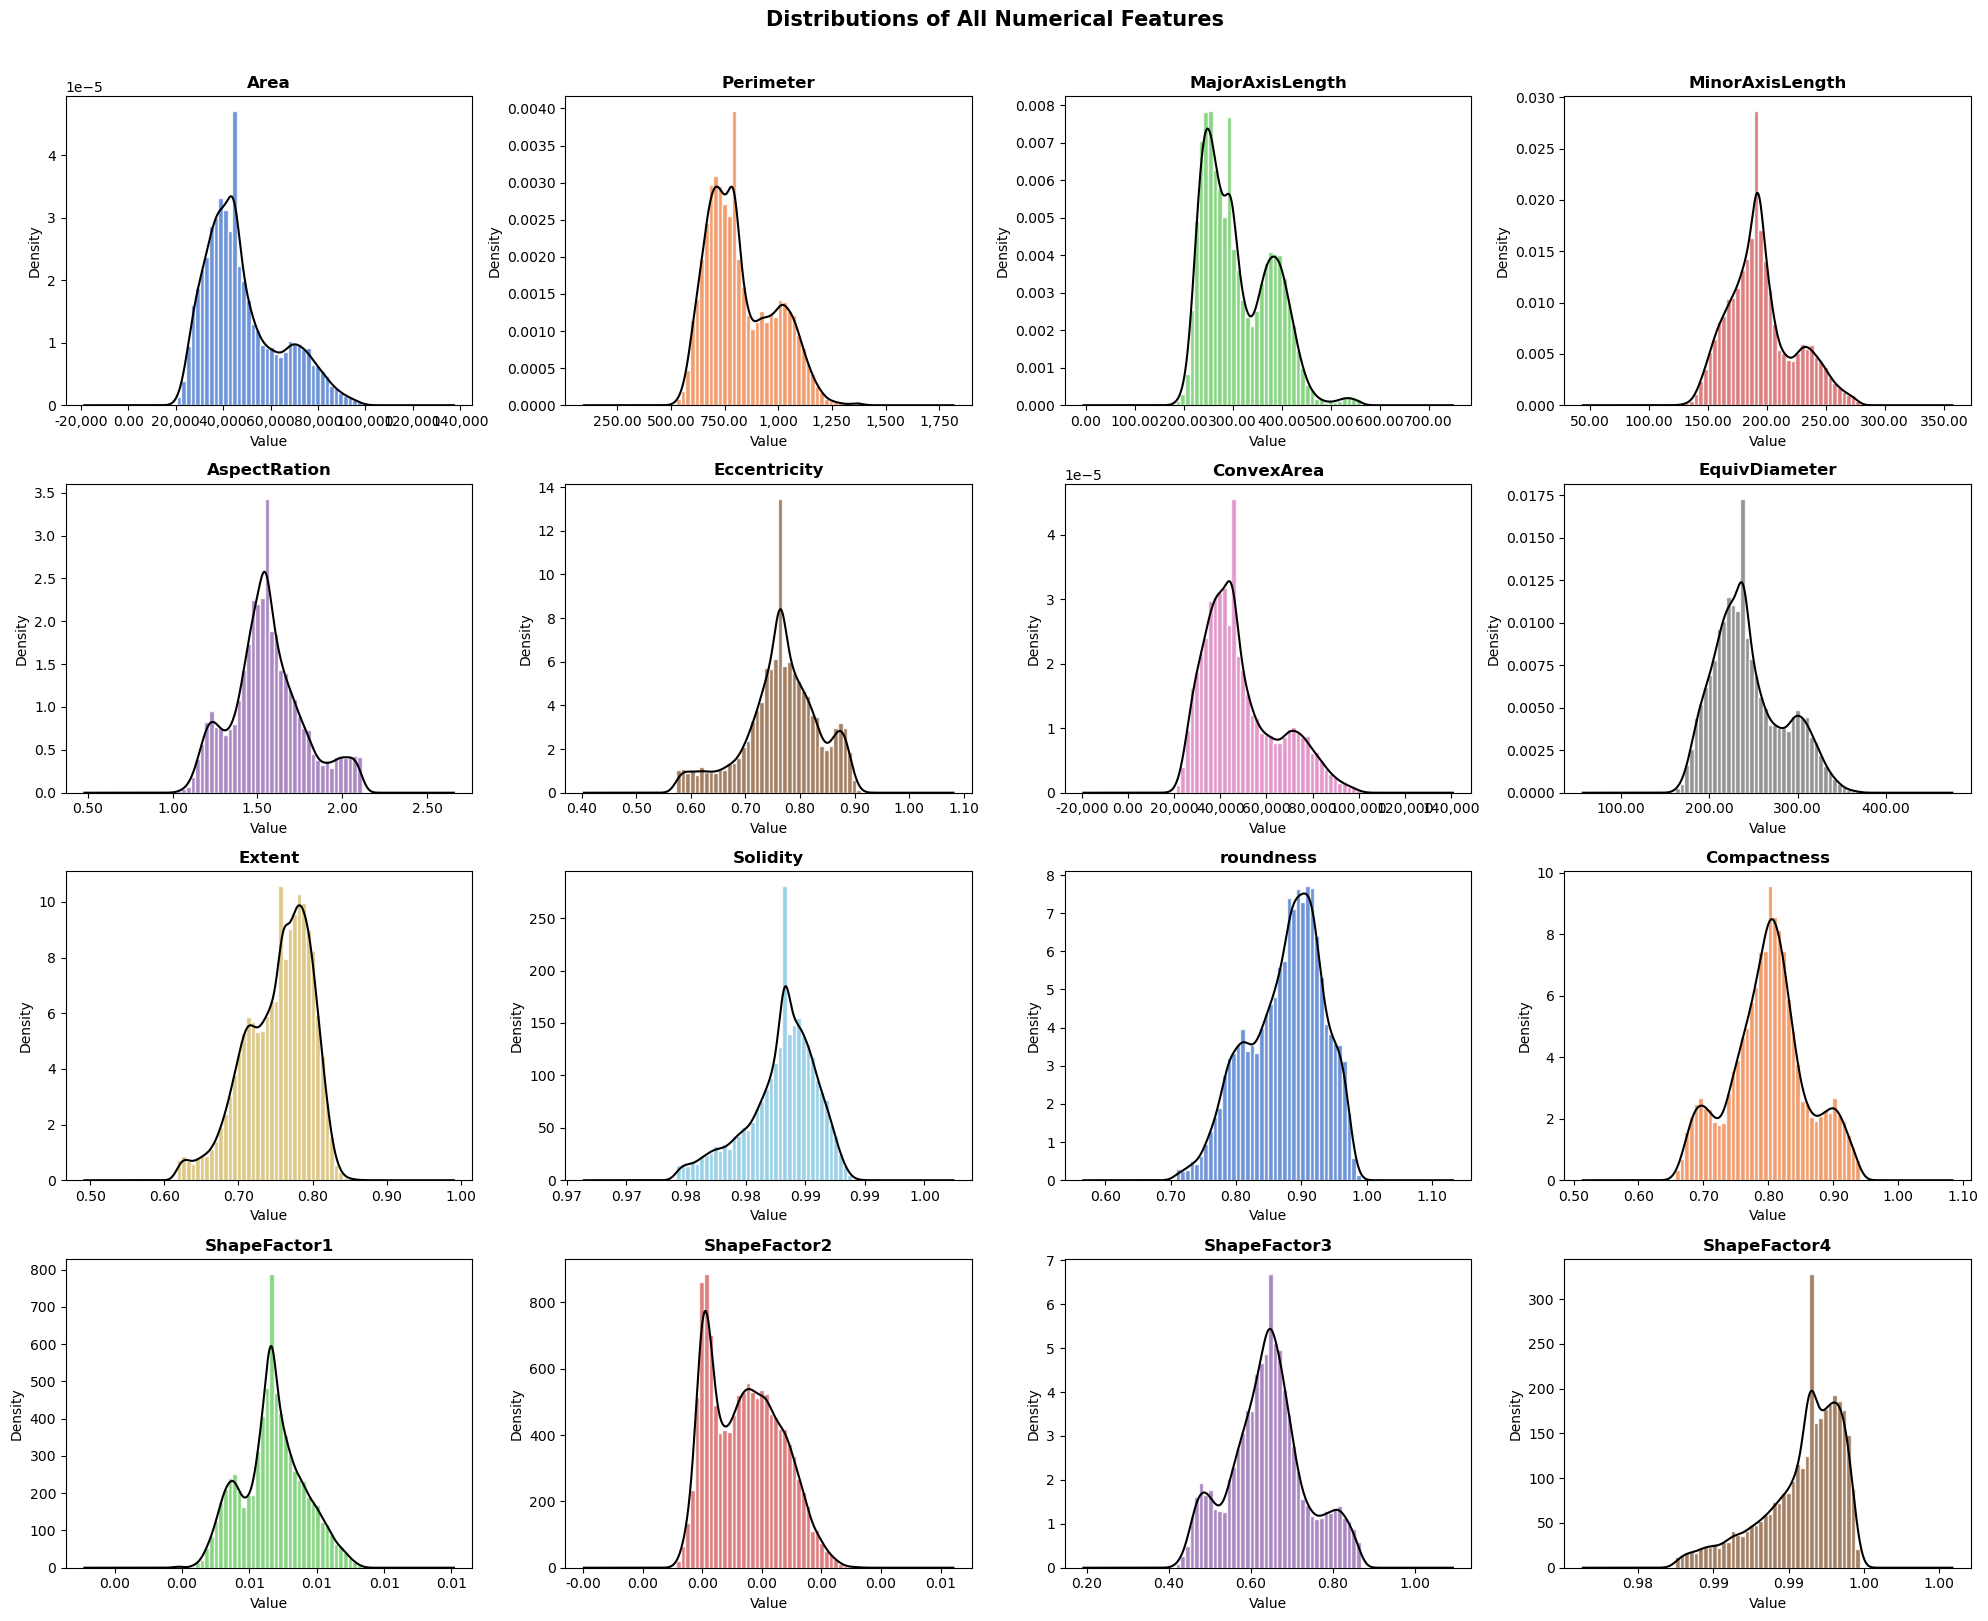

In [24]:
# Create a grid of subplots
# 4x4 grid for 16 features
fig, axes = plt.subplots(4, 4, figsize=(20, 16))   # 4x4 grid for 16 features
axes = axes.flatten()                             

# Color palette for each feature
colors = sns.color_palette('muted', len(numeric_cols))

# Loop through each numeric column
for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # Histogram
    ax.hist(df[col],bins=40,color=colors[i],edgecolor='white',alpha=0.8,density=True)

    # KDE curve overlay
    df[col].plot(kind='kde',ax=ax,color='black',linewidth=1.5)

    # Title and labels
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)

    # format the numbers
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'{x:,.0f}' if abs(x) > 999 else f'{x:.2f}'
        )
    )

plt.suptitle(
    'Distributions of All Numerical Features',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

Class Distribution

compute class counts and percentages

In [25]:
class_counts = df['Class'].value_counts().sort_values(ascending=False)
class_pct    = (class_counts / len(df) * 100).round(1)

Creating a figure with 2 subplots

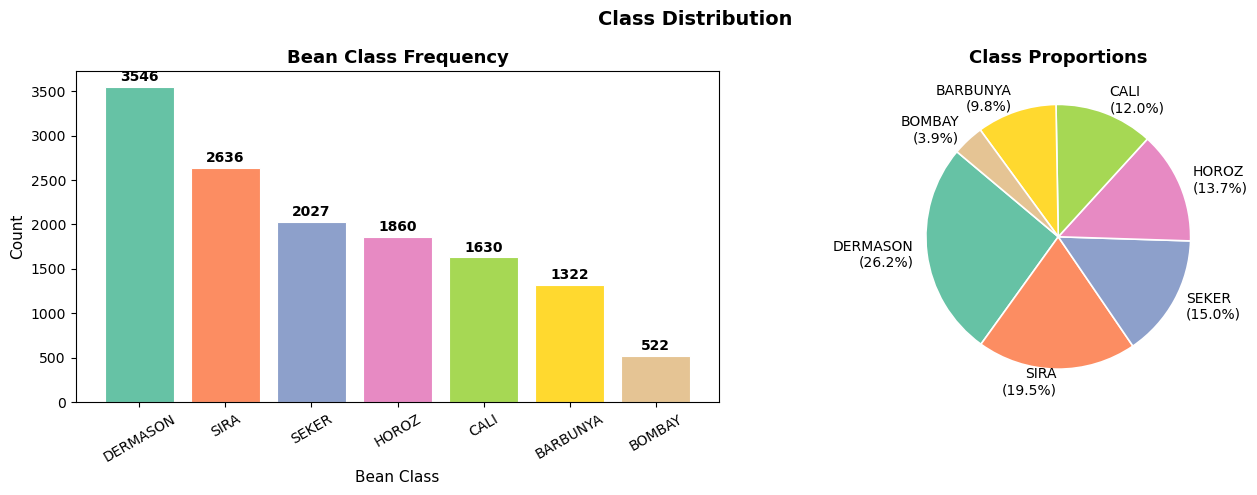

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1. BAR CHART
bars = axes[0].bar(class_counts.index,class_counts.values,color=sns.color_palette('Set2', len(class_counts)),edgecolor='white',linewidth=0.8)

# Add labels above the bar in the bar chart
for bar, val in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(val),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

axes[0].set_title('Bean Class Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bean Class', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# 2. PIE CHART
axes[1].pie(
    class_counts.values,
    labels=[f'{c}\n({p}%)' for c, p in zip(class_counts.index, class_pct)],
    colors=sns.color_palette('Set2', len(class_counts)),
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()

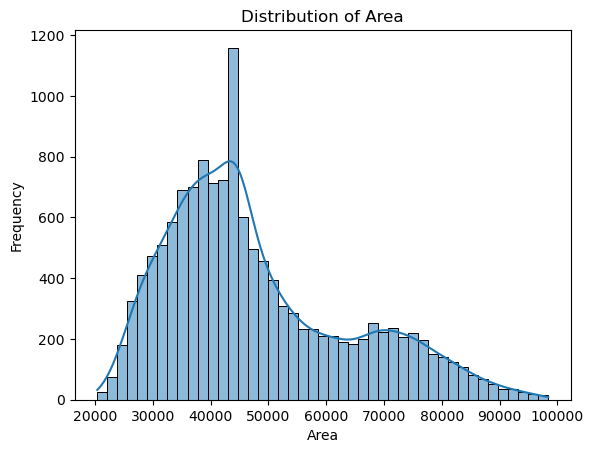

In [27]:
sns.histplot(df['Area'], kde=True)
plt.title("Distribution of Area")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

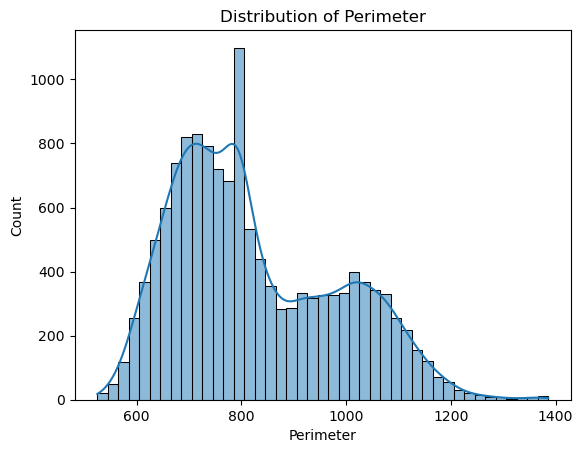

In [28]:
sns.histplot(data=df,x='Perimeter',kde=True)
plt.title("Distribution of Perimeter")
plt.show()

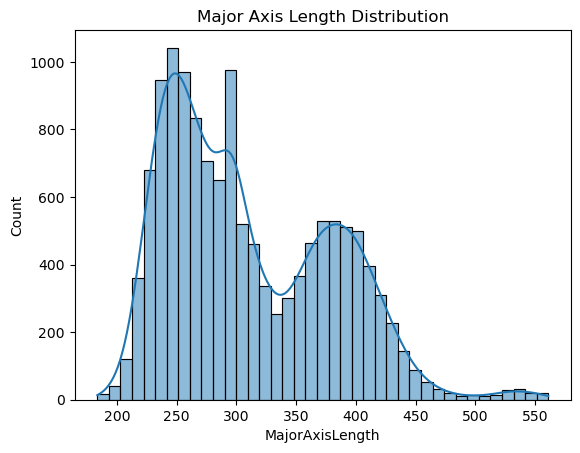

In [29]:
sns.histplot(df['MajorAxisLength'], kde=True)
plt.title("Major Axis Length Distribution")
plt.show()

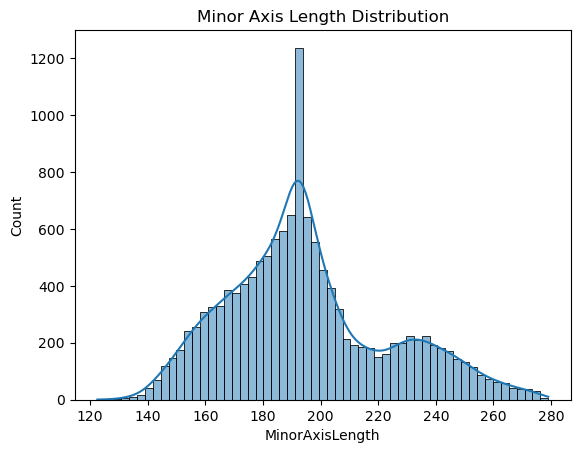

In [30]:
sns.histplot(df['MinorAxisLength'], kde=True)
plt.title("Minor Axis Length Distribution")
plt.show()

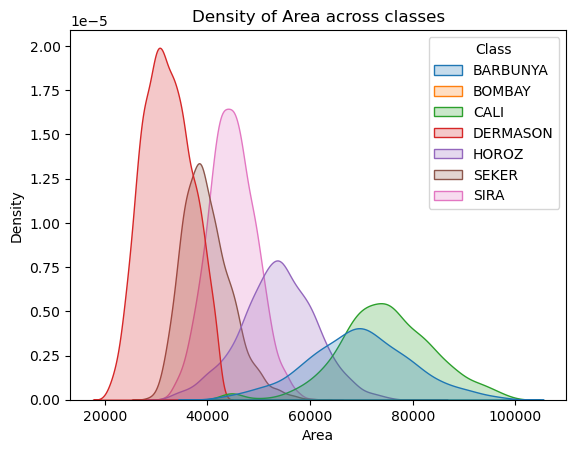

In [31]:
sns.kdeplot(data=df, x='Area', hue='Class', fill=True)
plt.title("Density of Area across classes")
plt.show()

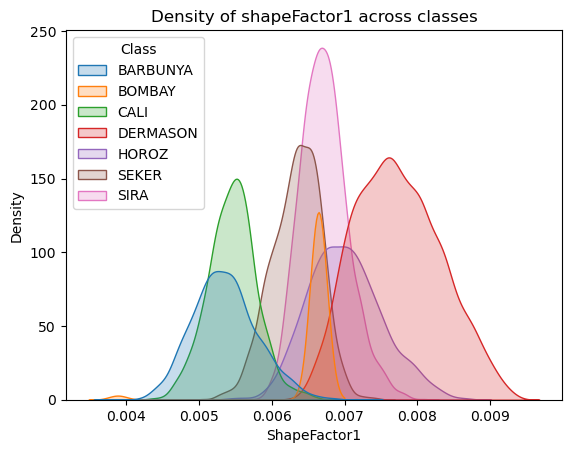

In [32]:
sns.kdeplot(data=df, x='ShapeFactor1', hue='Class', fill=True)
plt.title("Density of shapeFactor1 across classes")
plt.show()

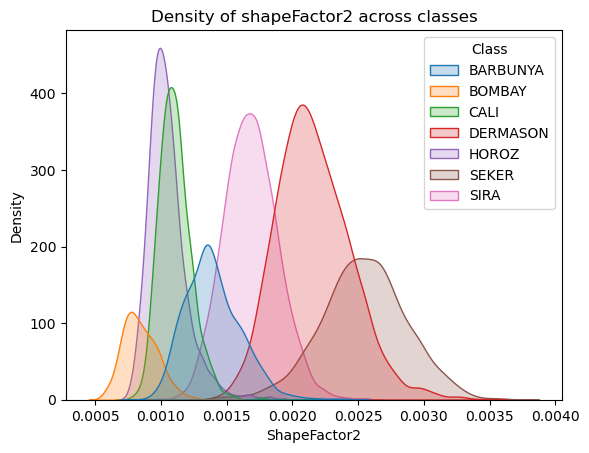

In [33]:
sns.kdeplot(data=df, x='ShapeFactor2', hue='Class', fill=True)
plt.title("Density of shapeFactor2 across classes")
plt.show()

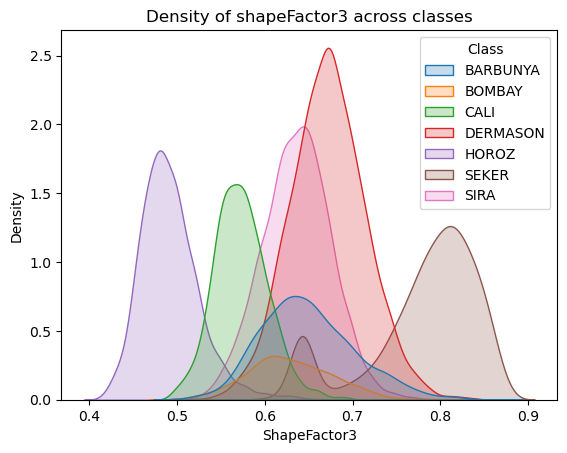

In [34]:
sns.kdeplot(data=df, x='ShapeFactor3', hue='Class', fill=True)
plt.title("Density of shapeFactor3 across classes")
plt.show()

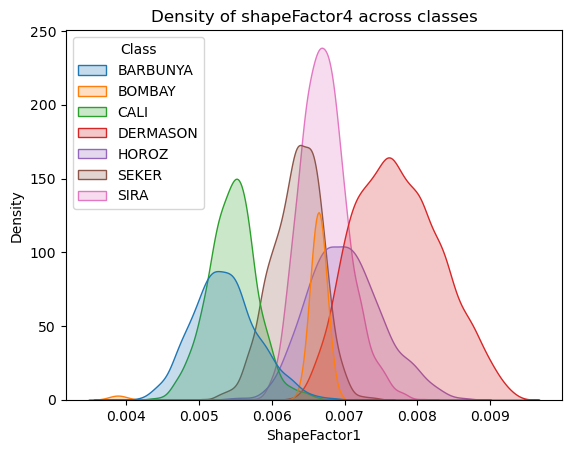

In [35]:
sns.kdeplot(data=df, x='ShapeFactor1', hue='Class', fill=True)
plt.title("Density of shapeFactor4 across classes")
plt.show()

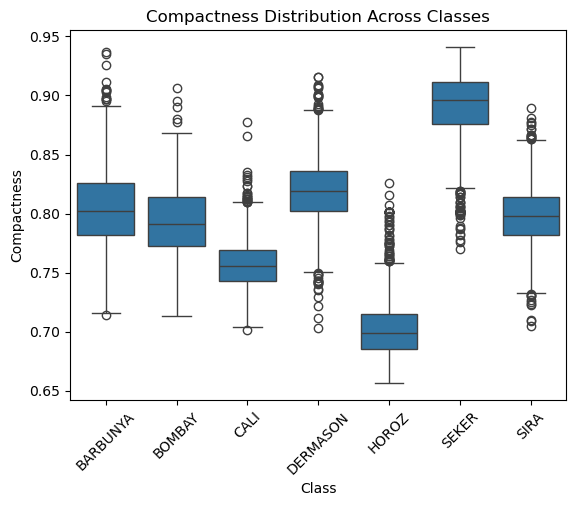

In [36]:
sns.boxplot(x='Class', y='Compactness', data=df)
plt.title("Compactness Distribution Across Classes")
plt.xticks(rotation=45)
plt.show()


In [39]:
# sns.swarmplot(x='Class', y='roundness', data=df)
# plt.title("Roundness across classes (Swarm Plot)")
# plt.show()

### Relationships

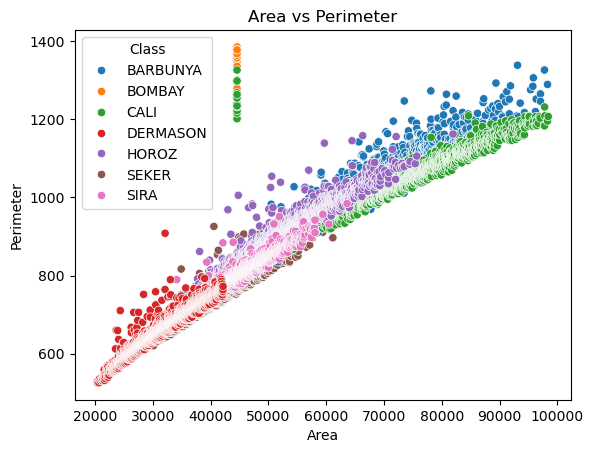

In [40]:
sns.scatterplot(x='Area', y='Perimeter', hue='Class', data=df)
plt.title("Area vs Perimeter")
plt.show()

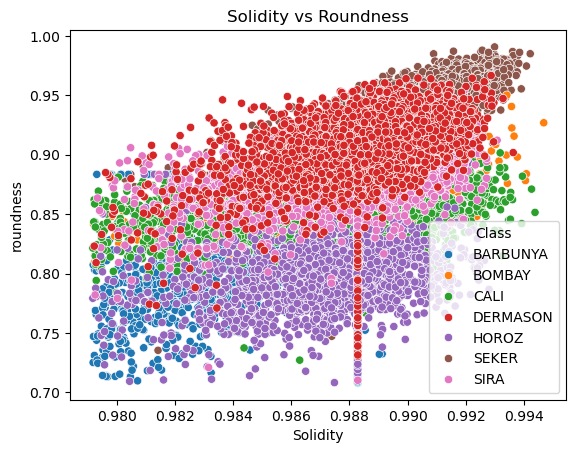

In [41]:
sns.scatterplot(x='Solidity', y='roundness', hue='Class', data=df)
plt.title("Solidity vs Roundness")
plt.show()

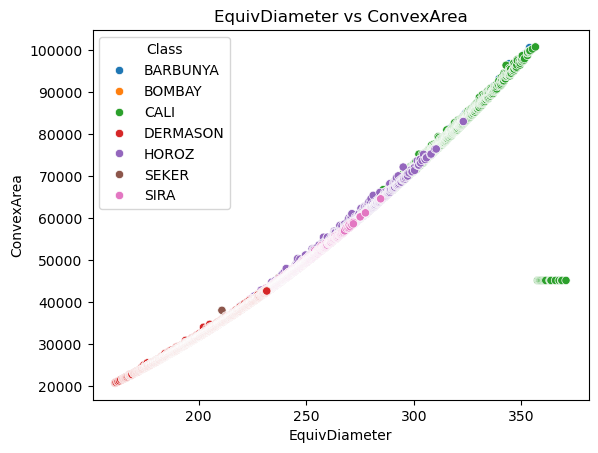

In [42]:
sns.scatterplot(x='EquivDiameter', y='ConvexArea', hue='Class', data=df)
plt.title("EquivDiameter vs ConvexArea")
plt.show()

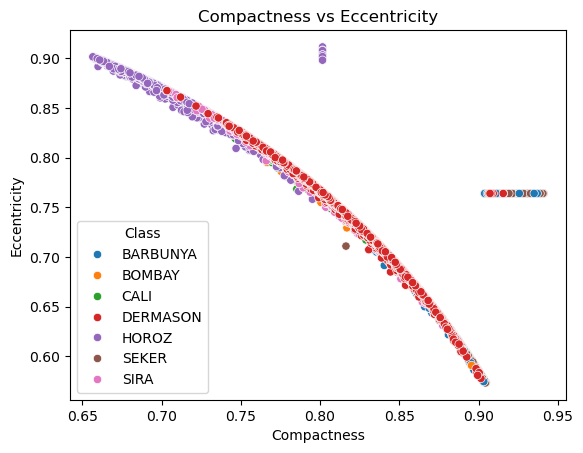

In [43]:
sns.scatterplot(data=df,x='Compactness',y='Eccentricity',hue='Class')
plt.title("Compactness vs Eccentricity")
plt.show()

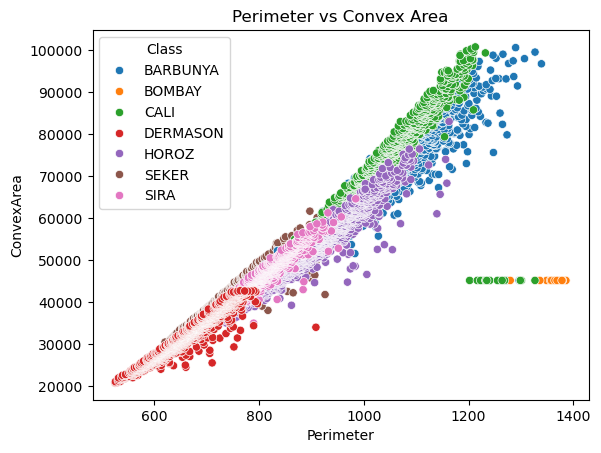

In [44]:
sns.scatterplot(data=df,x='Perimeter',y='ConvexArea',hue='Class')
plt.title("Perimeter vs Convex Area")
plt.show()

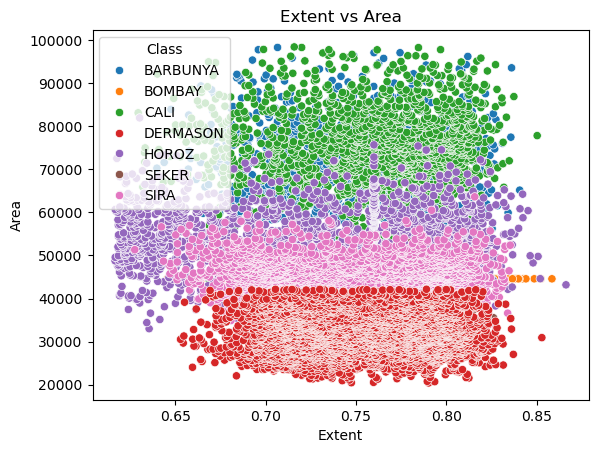

In [45]:
sns.scatterplot(data=df,x='Extent',y='Area',hue='Class')
plt.title("Extent vs Area")
plt.show()

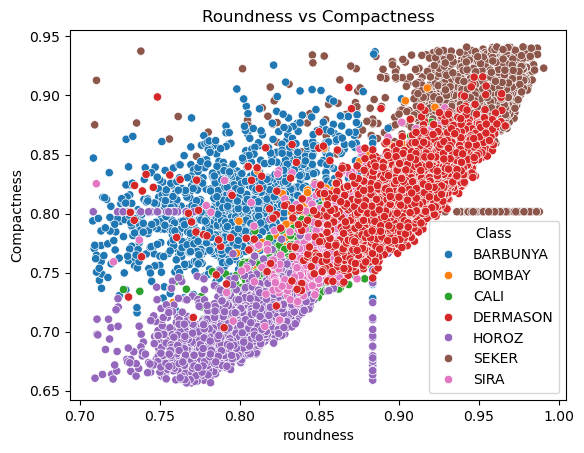

In [46]:
sns.scatterplot(data=df,x='roundness',y='Compactness',hue='Class')
plt.title("Roundness vs Compactness")
plt.show()

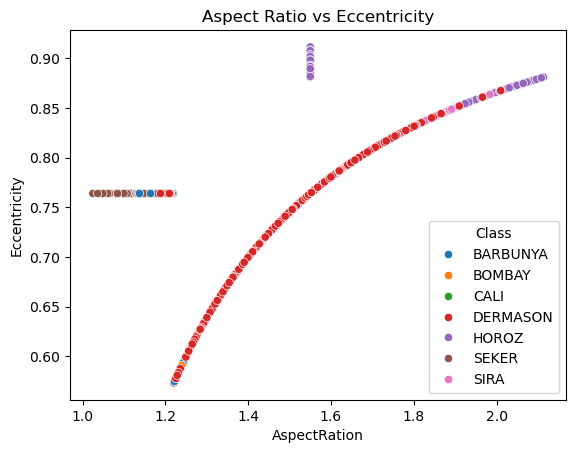

In [47]:
sns.scatterplot(data=df,x='AspectRation',y='Eccentricity',hue='Class')
plt.title("Aspect Ratio vs Eccentricity")
plt.show()

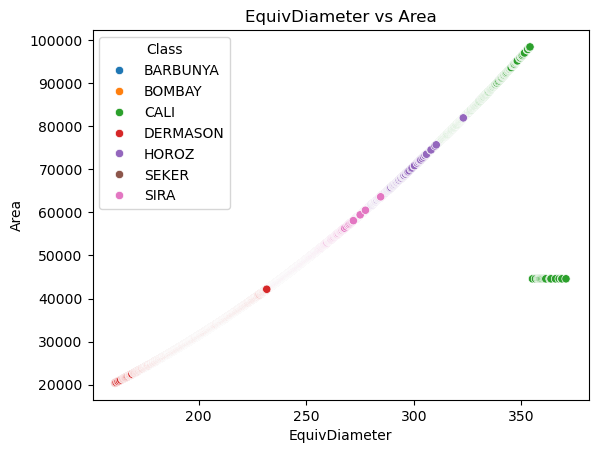

In [48]:
sns.scatterplot(data=df,x='EquivDiameter',y='Area',hue='Class')
plt.title("EquivDiameter vs Area")
plt.show()

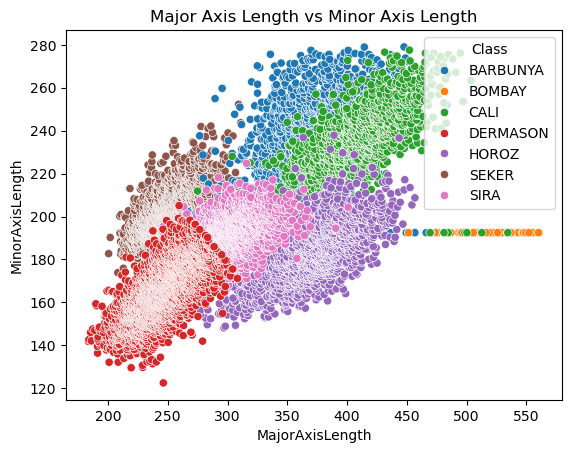

In [49]:
sns.scatterplot(data=df,x='MajorAxisLength',y='MinorAxisLength',hue='Class')
plt.title("Major Axis Length vs Minor Axis Length")
plt.show()

## Data modelling 

#### 1. Feature Selection and train-test split

In [50]:
X = df.drop('Class',axis=1)

In [51]:
y = df['Class']

In [52]:
print("Features Shape:", X.shape)

Features Shape: (13543, 16)


In [53]:
print("Target Shape:", y.shape)

Target Shape: (13543,)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [55]:
X_train.shape

(10834, 16)

In [56]:
X_test.shape

(2709, 16)

In [57]:
print("Class distribution in training set:")
print(y_train.value_counts())

Class distribution in training set:
Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


#### 2. Feature Scaling

In [58]:
scaler = StandardScaler()

In [59]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model 1: K-Nearest Neighbors (KNN) 

##### initial model

In [ ]:
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_scaled, y_train)
y_pred_knn_base = knn_base.predict(X_test_scaled)
knn_base.fit(X_train_scaled, y_train)
y_pred_knn_base = knn.predict(X_test_scaled)

NameError: name 'KNeighborsClassifier' is not defined

In [61]:
print(f'The accuracy score base model: {accuracy_score(y_test, y_pred_knn_base):.4f}')

NameError: name 'y_pred_knn_base' is not defined

##### hyperparameter tunning

In [62]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11],'weights': ['uniform', 'distance'],'metric': ['euclidean', 'manhattan']}

In [63]:
grid_knn = GridSearchCV(KNeighborsClassifier(),param_grid_knn,cv=5,scoring='accuracy',n_jobs=-1)

In [64]:
grid_knn.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [ ]:
best_knn = grid_knn.best_estimator_

In [ ]:
print("\nBest KNN Parameters:")
print(grid_knn.best_params_)

In [ ]:
print("\nBest Cross Validation Score:")
print(grid_knn.best_score_)

In [ ]:
y_pred_best_knn = best_knn.predict(X_test_scaled)

In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_best_knn)

In [ ]:
print("\nKNN Test Accuracy:")
print(knn_accuracy)

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_knn))


In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_best_knn)

In [ ]:
cm_knn

In [ ]:
sns.heatmap(cm_knn,annot=True,fmt='d',cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()